In [1]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import build_optimizer, fit_2D, fit_3D
from utils.loss_functions import recon_loss
from models.alzheimers_cure_2d import VAE
from models.alzheiminator_3d import ResidualUNet3D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


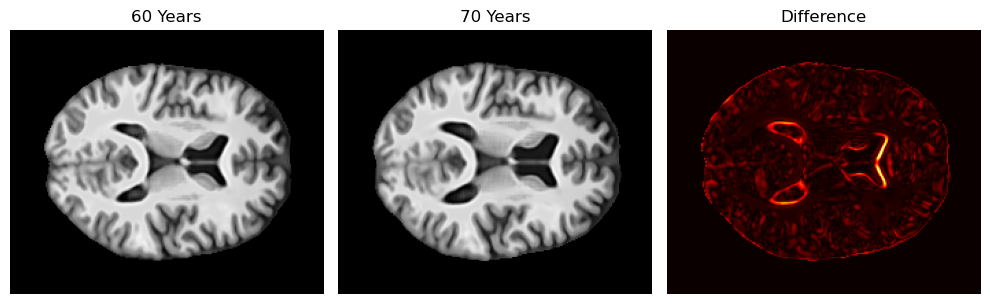

In [4]:
middle_h3 = data_loader.get_slice(training_pairs[100][0], index=90)
middle_h4 = data_loader.get_slice(training_pairs[100][1], index=90)

difference = np.abs(middle_h3 - middle_h4)
data_loader.display_slices([middle_h3, middle_h4, difference], ["60 Years", "70 Years", "Difference"], slice_colors=["gray", "gray", "hot"])

## Combined Dice + Volumetric Difference Loss

The `combined_dice_volume_loss` combines two complementary loss functions:
1. **Dice Loss**: Measures the overlap between predicted and target probability maps
2. **Volumetric Difference Loss**: Penalizes differences in total volume between predictions and targets

This is useful for 3D medical image segmentation/reconstruction tasks where both spatial overlap and volume preservation are important.

In [5]:
#model = ResidualUNet3D(in_ch=1, base=32).to(device)

# Load existing model from out/unets
model = ResidualUNet3D(in_ch=1, base=32).to(device)
model.load_state_dict(torch.load("out/unets/3d_unet_model_0.0676.pt"))

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

print(len(training_pairs), "training pairs")

562 training pairs


In [ ]:
# Define the combined loss function
def criterion(output, target):
    recon = recon_loss(output, target)
    return recon

# Use with fit_3D
model, _, snapshots = fit_3D(
    model=model,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    criterion=criterion,  # Pass the combined loss
    epochs=1001,
    print_every=100,
    save_every=100
)

[Iter 0] total: 0.064787 (custom criterion) + TV
Saved snapshot at iter 0 (mid-axial slice)
[Iter 100] total: 0.061761 (custom criterion) + TV
Saved snapshot at iter 100 (mid-axial slice)
[Iter 200] total: 0.061915 (custom criterion) + TV
Saved snapshot at iter 200 (mid-axial slice)
[Iter 300] total: 0.066558 (custom criterion) + TV
Saved snapshot at iter 300 (mid-axial slice)
[Iter 400] total: 0.061677 (custom criterion) + TV
Saved snapshot at iter 400 (mid-axial slice)
[Iter 500] total: 0.062042 (custom criterion) + TV
Saved snapshot at iter 500 (mid-axial slice)
[Iter 600] total: 0.061141 (custom criterion) + TV
Saved snapshot at iter 600 (mid-axial slice)
[Iter 700] total: 0.061810 (custom criterion) + TV
Saved snapshot at iter 700 (mid-axial slice)
[Iter 800] total: 0.056931 (custom criterion) + TV
Saved snapshot at iter 800 (mid-axial slice)
[Iter 900] total: 0.071880 (custom criterion) + TV
Saved snapshot at iter 900 (mid-axial slice)
[Iter 1000] total: 0.058094 (custom criterio

Displaying snapshot from pair 0, loss: 0.0648


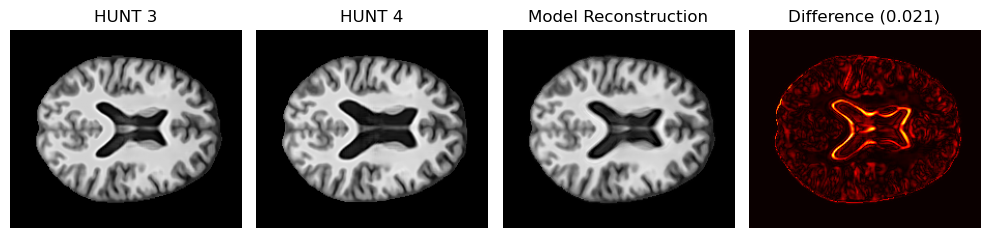

Displaying snapshot from pair 100, loss: 0.0618


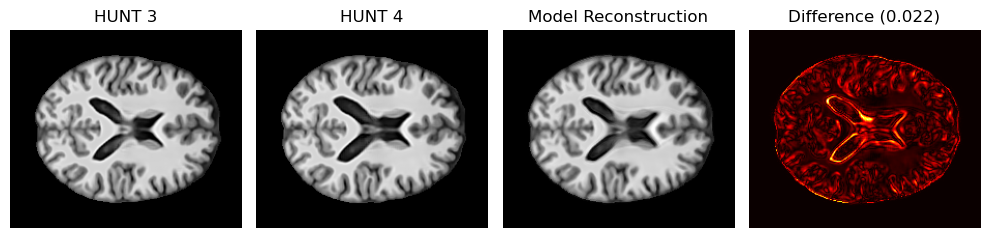

Displaying snapshot from pair 200, loss: 0.0619


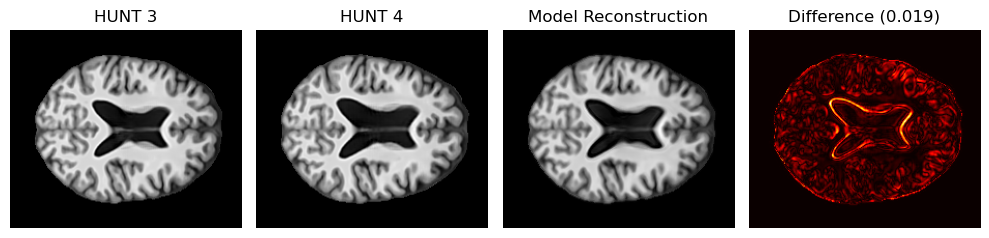

Displaying snapshot from pair 300, loss: 0.0666


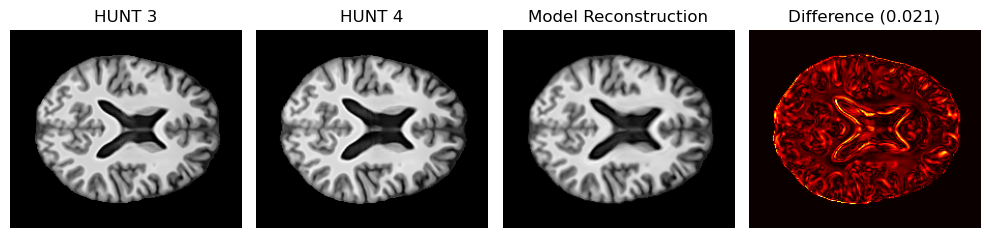

Displaying snapshot from pair 400, loss: 0.0617


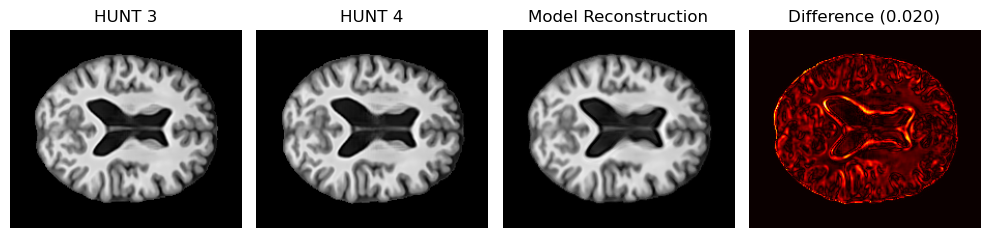

Displaying snapshot from pair 500, loss: 0.0620


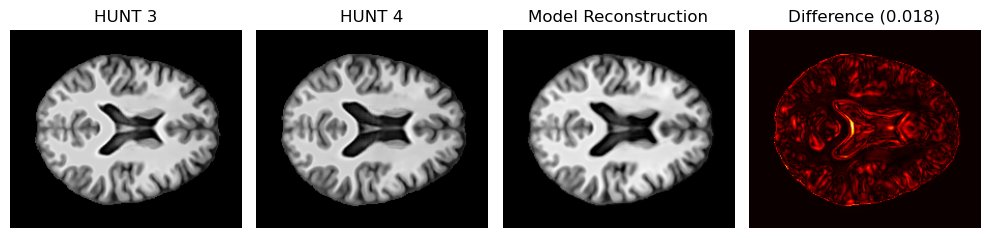

Displaying snapshot from pair 600, loss: 0.0611


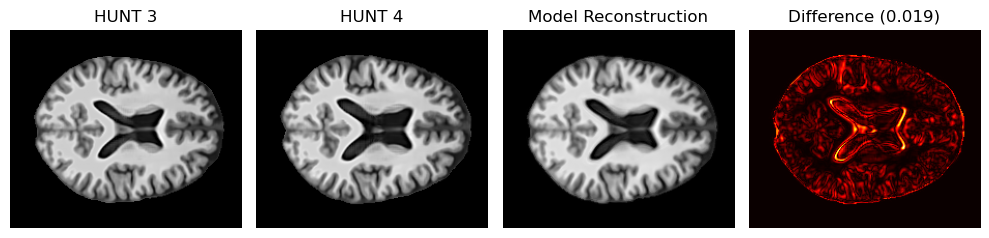

Displaying snapshot from pair 700, loss: 0.0618


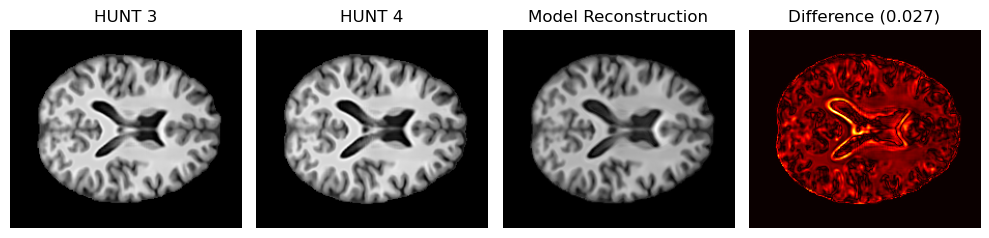

Displaying snapshot from pair 800, loss: 0.0569


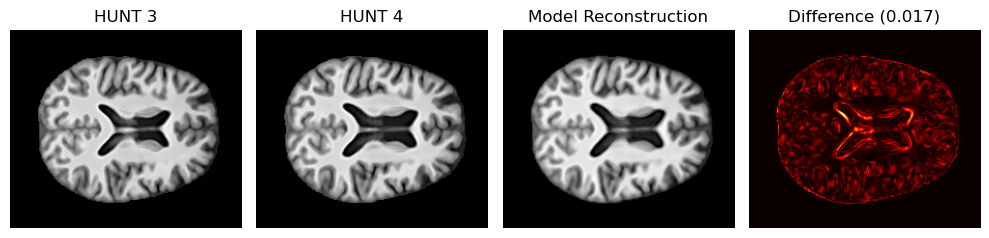

Displaying snapshot from pair 900, loss: 0.0719


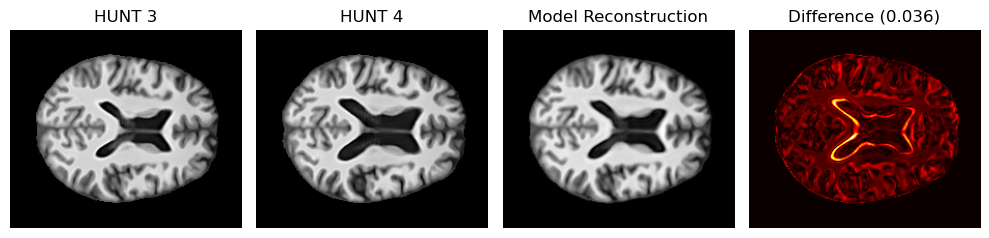

Displaying snapshot from pair 1000, loss: 0.0581


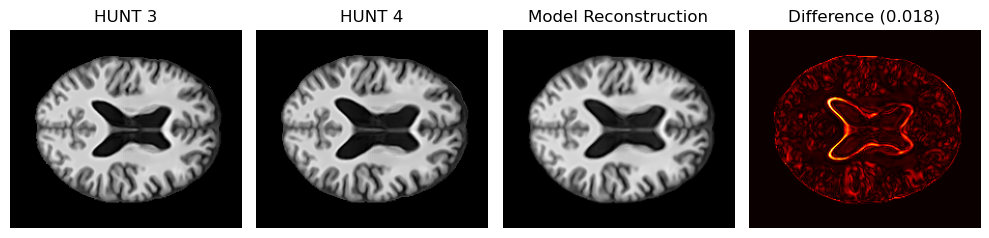

In [7]:
for snapshot in snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}, loss: {snapshot['loss']:.4f}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "Model Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [8]:
# Save the final model to /out directory
output_dir = "out/unets"
os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, "3d_unet_model_" + snapshots[-1]['loss'].__str__()[:6] + ".pt")
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to out/unets/3d_unet_model_0.0580.pt
